# Practice 7 — pandas + NumPy
Work through each task in order. Try to solve it yourself before looking anything up!

In [1]:
import pandas as pd
import numpy as np

---
## Level 1 — Basics

### Task 1: Create & Summarise
1. Create a DataFrame with 6 rows representing books. Columns: `title`, `genre` (Fiction, Non-Fiction, or Science), `price` (float), `copies_sold` (integer)
2. Add a `revenue` column = price × copies_sold
3. Use `.value_counts()` to count books per genre
4. Use `np.log()` to add a `log_revenue` column

In [10]:
# 1. Create the DataFrame

data = {
    'title': ['tomorrow','today','yesterday','war','peace','noise'],
    'genre': ['fiction','fiction','non-fiction','science','romance','life'],
    'price': [2.5,3.4,5,6,7,5.3],
    'copies_sold': [20,30,10,40,20,60]

}
books = pd.DataFrame(data)
# 2. Add revenue column
books['revenue'] = books['price'] * books['copies_sold']

# 3. Count books per genre
books['genre'].value_counts()
# 4. Add log_revenue column
books['log_revenue'] = np.log(books['revenue'])


### Task 2: Inspect & Describe
Run the cell below to load a dataset, then:
1. Use `.info()` and `.describe()` to explore it
2. Find the mean, median, and std of `body_mass_g`
3. What percentage of penguins have body mass above the mean?
4. Use `np.percentile()` to find the 25th, 50th, and 75th percentiles of `flipper_length_mm`

In [11]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
penguins = pd.read_csv(url)
penguins = penguins.dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [15]:
# 1. Explore with .info() and .describe()

penguins.describe()
penguins.info()

# 2. Mean, median, std of body_mass_g
np.mean(penguins['body_mass_g'])
np.median(penguins['body_mass_g'])
np.std(penguins['body_mass_g'])

# 3. Percentage above the mean
np.mean(penguins['body_mass_g']>np.mean(penguins['body_mass_g']))

# 4. 25th, 50th, 75th percentiles of flipper_length_mm
np.percentile(penguins['flipper_length_mm'],[25,50,75])


<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


array([190., 197., 213.])

### Task 3: Duplicates & Unique Values
A DataFrame has been created for you.
1. Find and remove duplicate rows
2. Use `.value_counts()` on the `city` column
3. Use `np.unique()` with `return_counts=True` on the `category` column

In [20]:
# Starter data — don't change this
events = pd.DataFrame({
    'event_id':  [1, 2, 3, 2, 4, 5, 3],
    'city':      ['Tokyo', 'Paris', 'NYC', 'Paris', 'Tokyo', 'London', 'NYC'],
    'category':  ['Music', 'Sports', 'Music', 'Sports', 'Food', 'Music', 'Music'],
    'attendees': [200, 450, 300, 450, 150, 500, 300],
})

# 1. Find and remove duplicates
events.drop_duplicates()
events.duplicated()
# 2. value_counts on city
events['city'].value_counts()

# 3. np.unique on category
np.unique(events['category'],return_counts=True)


(array(['Food', 'Music', 'Sports'], dtype=object), array([1, 4, 2]))

---
## Level 2 — Transformations

### Task 4: String Operations
A DataFrame of product names has been created for you.
1. Use `.str.upper()` to add an `name_upper` column with names in uppercase
2. Use `.str.replace()` to add a `name_clean` column — replace all underscores `_` with spaces
3. Use `.str.len()` to add a `name_len` column with the length of each name
4. Use `.str.contains()` to filter to only products that contain the word `'pro'` (case-insensitive)

In [ ]:
# Starter data — don't change this
products = pd.DataFrame({
    'name':  ['wireless_headphones', 'gaming_mouse', 'usb_hub_pro', 'mechanical_keyboard', 'webcam_pro', 'hdmi_cable'],
    'price': [79.99, 49.99, 29.99, 119.99, 89.99, 14.99],
})

# 1. Uppercase name
products['name_upper'] = products['name'].str.upper()

# 2. Replace underscores with spaces

products['name_clean'] = products['name'].str.replace('_',' ')
# 3. Length of name
products['name_len'] = products['name'].str.len()

# 4. Filter to products containing 'pro'
products = products[products['name'].str.contains('pro',case=False)]
products

,name,price,name_upper,name_clean,name_len
2,usb_hub_pro,29.99,USB_HUB_PRO,usb hub pro,11
4,webcam_pro,89.99,WEBCAM_PRO,webcam pro,10


### Task 5: Bin & Transform
A DataFrame of patient data has been created for you.
1. Use `pd.cut()` to add a `bmi_category` column:
   - Below 18.5 → `'Underweight'`, 18.5–24.9 → `'Normal'`, 25–29.9 → `'Overweight'`, 30+ → `'Obese'`
2. Use `np.clip()` to cap `blood_pressure` between the 10th and 90th percentile, store as `bp_clipped`
3. Use `np.where()` to add a `high_bp` column — `True` if `bp_clipped` > 130, `False` otherwise

In [36]:
# Starter data — don't change this
np.random.seed(4)
patients = pd.DataFrame({
    'patient_id':     range(1, 13),
    'bmi':            np.random.uniform(16, 38, size=12).round(1),
    'blood_pressure': np.random.randint(90, 180, size=12),
})

# 1. Add bmi_category using pd.cut()
patients['bmi_category'] = pd.cut(patients['bmi'],
                                  bins = [0,18.4,24.8,29.8,100],
                                  labels=['Underweight','Normal','Overweight','Obese'])
patients
# 2. Clip blood_pressure between 10th and 90th percentile
p10,p90 =np.percentile(patients['blood_pressure'],[10,90])
patients['bp_clipped']= np.clip(patients['blood_pressure'],p10,p90)

# 3. Add high_bp column using np.where()
patients['high_bp'] = np.where(patients['blood_pressure']>130,True,False)
patients

,patient_id,bmi,blood_pressure,bmi_category,bp_clipped,high_bp
0,1,37.3,142,Obese,142.0,True
1,2,28.0,93,Overweight,94.8,False
2,3,37.4,90,Obese,94.8,False
3,4,31.7,145,Obese,145.0,True
4,5,31.4,111,Obese,111.0,False
5,6,20.8,111,Normal,111.0,False
6,7,37.5,163,Obese,155.0,True
7,8,16.1,128,Underweight,128.0,False
8,9,21.6,146,Normal,146.0,True
9,10,25.6,156,Overweight,155.0,True


### Task 6: Missing Data
A DataFrame with missing values has been created for you.
1. Count nulls per column
2. Find the nanmean, nanmedian, and nanstd of `salary`
3. Fill missing `salary` values with the nanmedian
4. Fill missing `department` values with the string `'Unknown'`

In [ ]:
# Starter data — don't change this
staff = pd.DataFrame({
    'name':       ['Alice', 'Bob', 'Carol', 'Dave', 'Emma', 'Frank', 'Grace'],
    'department': ['HR', None, 'Engineering', 'Sales', None, 'Engineering', 'HR'],
    'salary':     [55000, 62000, np.nan, 48000, 71000, np.nan, 59000],
})

# 1. Count nulls per column
staff.isnull().sum()

# 2. nanmean, nanmedian, nanstd of salary
np.nanmean(staff['salary'])
md = np.nanmedian(staff['salary'])
np.nanstd(staff['salary'])

# 3. Fill missing salary with nanmedian
staff.loc[staff['salary'].isna(),'salary']=md
staff['salary'] = staff['salary'].fillna(md)
staff
# 4. Fill missing department with 'Unknown'
#staff.loc[staff['department']=='None','department']='Unknown'
staff['department'] = staff['department'].fillna('Unknown')


,name,department,salary
0,Alice,HR,55000.0
1,Bob,None,62000.0
2,Carol,Engineering,59000.0
3,Dave,Sales,48000.0
4,Emma,None,71000.0
5,Frank,Engineering,59000.0
6,Grace,HR,59000.0


---
## Level 3 — Aggregation

### Task 7: GroupBy + Pivot Table
Using the `sales` DataFrame below:
1. Group by `region` and find the total and mean `revenue` using `.agg()`
2. Use `pd.pivot_table()` to create a table showing mean `revenue` for each `region` × `product` combination (hint: `pd.pivot_table(df, values=..., index=..., columns=..., aggfunc=...)`)
3. Use `np.argsort()` to sort the `rep` column by `revenue` (lowest to highest)

In [50]:
# Starter data — don't change this
sales = pd.DataFrame({
    'rep':     ['Alice', 'Bob', 'Carol', 'Dave', 'Emma', 'Frank'],
    'region':  ['North', 'South', 'North', 'East', 'South', 'East'],
    'product': ['Widget', 'Gadget', 'Gadget', 'Widget', 'Widget', 'Gadget'],
    'revenue': [4200, 3150, 5800, 4700, 3900, 5100],
})

# 1. GroupBy region: total and mean revenue
sales.groupby('region')['revenue'].agg(['sum', 'mean'])

# 2. Pivot table: mean revenue per region × product
pt = pd.pivot_table(sales, values = 'revenue',
                    index = 'region',
                    columns= 'product')
pt
# 3. Sort reps by revenue using np.argsort()
sales['rep'].to_numpy()[np.argsort(sales['revenue'])]

array(['Bob', 'Emma', 'Alice', 'Dave', 'Frank', 'Carol'], dtype=object)

### Task 8: Rolling Average
A time series DataFrame has been created for you.
1. Add a `rolling_avg` column with a **7-day rolling mean**
2. Find the correlation between `temperature` and `rolling_avg` using `np.corrcoef()` (drop NaN rows first)
3. Plot both columns on the same chart

<Axes: xlabel='date'>

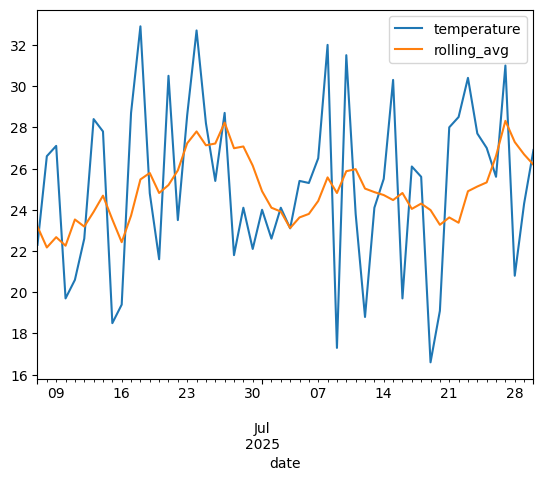

In [56]:
# Starter data — don't change this
np.random.seed(11)
dates = pd.date_range('2025-06-01', periods=60, freq='D')
weather = pd.DataFrame({
    'date':        dates,
    'temperature': np.random.normal(25, 5, size=60).round(1),
})
weather = weather.set_index('date')

# 1. Add 7-day rolling average
weather['rolling_avg']=weather['temperature'].rolling(7).mean()
weather
# 2. Correlation between temperature and rolling_avg
weather = weather.dropna()
np.corrcoef(weather['temperature'],weather['rolling_avg'])

# 3. Plot both columns
weather[['temperature','rolling_avg']].plot()


### Task 9: Merge + Weighted Score
Two DataFrames are provided.
1. Merge `courses` and `grades` on `course_id`
2. Use `.groupby()` + `.apply()` with `np.dot()` to compute each student's **weighted GPA**
3. Add the result back to the `students` DataFrame as a `gpa` column

In [66]:
# Starter data — don't change this
students = pd.DataFrame({
    'student_id': [1, 2, 3],
    'name':       ['Alice', 'Bob', 'Carol'],
})

grades = pd.DataFrame({
    'student_id': [1, 1, 1, 2, 2, 2, 3, 3, 3],
    'course':     ['Math', 'Biology', 'History'] * 3,
    'score':      [3.8, 3.5, 3.2, 2.9, 3.7, 3.0, 3.5, 3.9, 3.3],
    'credits':    [4, 3, 3] * 3,   # weights are course credits
})

# 1. Merge students and grades
m = students.merge(grades, on='student_id',how='inner')

# 2. Weighted GPA per student using np.dot()
#    hint: weighted GPA = np.dot(scores, credits) / credits.sum()
wg = m.groupby('student_id').apply(lambda g: (np.dot(g['score'],g['credits']))/(g['credits'].sum()))
wg
# 3. Add gpa column to students DataFrame
students['gpa'] = students['student_id'].map(wg)

students

/var/folders/3r/5sttq01d46zg8zxyw17j5nbw0000gn/T/ipykernel_69137/935328188.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wg = m.groupby('student_id').apply(lambda g: (np.dot(g['score'],g['credits']))/(g['credits'].sum()))


,student_id,name,gpa
0,1,Alice,3.53
1,2,Bob,3.17
2,3,Carol,3.56


---
## Level 4 — Real-world

### Task 10: Full Pipeline
Load the tips dataset and run a full analysis:
1. Drop missing values
2. Use `.str.upper()` to standardise the `sex` column to uppercase
3. Add a `tip_pct` column = tip as a percentage of total_bill
4. Use `pd.cut()` to bin `tip_pct` into: Low (0–10%), Medium (10–20%), High (20%+)
5. Use `pd.pivot_table()` to show mean `tip_pct` for each `sex` × `day` combination
6. Normalize `total_bill` to 0–1 using min-max normalization
7. Find the correlation between `total_bill` and `tip` using `np.corrcoef()`

In [78]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)

# 1. Drop missing values
tips =tips.dropna()

# 2. Standardise sex column to uppercase
tips['sex'] = tips['sex'].str.upper()


# 3. Add tip_pct column
tips['tip_pct'] = tips['tip']/tips['total_bill']

# 4. Bin tip_pct into Low / Medium / High

pd.cut(tips['tip_pct'],
       bins=[0,0.1,0.2,1],labels=['low','medium','high'])
# 5. Pivot table: mean tip_pct per sex × day
pd.pivot_table(tips,
               values='tip_pct',
               index='sex',
               columns='day')

# 6. Normalize total_bill to 0-1
tb= tips['total_bill']
tb_norm = (tb-tb.min())/(tb.max()-tb.min())
tb_norm
# 7. Correlation between total_bill and tip
np.corrcoef(tips['total_bill'],tips['tip'])

array([[1.        , 0.67573411],
       [0.67573411, 1.        ]])

In [80]:
tips.groupby(['sex','day'])['tip_pct'].mean()

sex     day 
FEMALE  Fri     0.199388
        Sat     0.156470
        Sun     0.181569
        Thur    0.157525
MALE    Fri     0.143385
        Sat     0.151577
        Sun     0.162344
        Thur    0.165276
Name: tip_pct, dtype: float64